# **1. 가설 세우기**
- 비, 눈, 강한 바람, 낮은 기온 등 열악한 기상 환경일수록 자전거 대여량은 줄어들 것이다.
- 출퇴근 시간대(예: 오전 7–9시, 오후 5–7시)에 자전거 대여량이 높을 것이다.
- 공휴일이나 시스템 정상 운영일에 자전거 대여량이 더 많을 것이다.

# **2. 라이브러리 불러오기**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# **3. 데이터 불러오기**

### train 데이터 소개
- Date: 데이터가 수집된 날짜 (YYYY-MM-DD)
- Rented Bike Count: 해당 날짜, 시간대에 대여된 자전거 수 (종속 변수)
- Hour: 시간대 (24시간 기준, 0~23)	
- Temperature(째C): 해당 시간의 기온
- Humidity(%): 상대 습도(%)
- Wind speed (m/s): 풍속 (초당 바람의 세기)
- Visibility (10m): 시정 거리 
- Dew point temperature(째C): 이슬점 온도 (수증기가 이슬이 되기 시작하는 온도)
- Solar Radiation (MJ/m2): 시간당 태양 복사 에너지량
- Rainfall(mm): 강수량
- Snowfall (cm): 적설량
- Seasons: 계절(봄, 여름, 가을, 겨울)
- Holiday: 공휴일 여부 ('Holiday' or 'No Holiday')
- Functioning Day: 자전거 대여 시스템이 정상 운영된 날 여부 (Yes or No)

In [2]:
%pwd

'c:\\Users\\withk\\Baf\\BAF-17-Fresh-Edu\\3주차'

In [3]:
df = pd.read_csv('data/train.csv')
df

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


# **4. EDA**




### **4-1 데이터 살펴보기**

In [4]:
print(df.shape) #(8040, 14)
print(df.info())
display(df.head())
display(df.tail())

(8040, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8040 non-null   object 
 1   Rented Bike Count          8040 non-null   int64  
 2   Hour                       8040 non-null   int64  
 3   Temperature(째C)            7240 non-null   float64
 4   Humidity(%)                8040 non-null   int64  
 5   Wind speed (m/s)           7238 non-null   float64
 6   Visibility (10m)           8040 non-null   int64  
 7   Dew point temperature(째C)  8040 non-null   float64
 8   Solar Radiation (MJ/m2)    8040 non-null   float64
 9   Rainfall(mm)               8040 non-null   float64
 10  Snowfall (cm)              8040 non-null   float64
 11  Seasons                    7238 non-null   object 
 12  Holiday                    8040 non-null   object 
 13  Functioning Day            8040 non-n

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8039,31/10/2018,798,23,6.4,60,1.8,1930,-0.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [5]:
df.describe() # 기초통계량

,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8040.000000,8040.000000,7240.000000,8040.000000,7238.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000
mean,709.775995,11.500000,13.498564,58.271020,1.756756,1459.170896,4.522239,0.587072,0.152164,0.066493
std,657.320605,6.922617,12.270471,20.340492,1.045901,603.716284,13.393517,0.886186,1.127026,0.378182
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,43.000000,1.000000,977.000000,-4.600000,0.000000,0.000000,0.000000
50%,485.000000,11.500000,15.600000,57.000000,1.600000,1741.000000,6.400000,0.020000,0.000000,0.000000
75%,1080.500000,17.250000,23.300000,74.000000,2.400000,2000.000000,15.600000,0.960000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,5.100000


### **4-2 결측치 및 중복 데이터 확인**

In [6]:
df.isna().sum(axis=0).sort_values() #결측치 개수 오름차순 정렬

Date                           0
Rented Bike Count              0
Hour                           0
Humidity(%)                    0
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Holiday                        0
Functioning Day                0
Temperature(째C)              800
Wind speed (m/s)             802
Seasons                      802
dtype: int64

### **4-2.1 날짜(seasons) 결측치 -> 날짜(month)를 기반으로 유추**
- 3~5월: Spring
- 6~8월: Summer
- 9~11월: Autumn
- 12~2월: Winter
-> 이것은 각 seasons의 Nan 값을 mean, median 등의 값으로 대체하는 것보다 명확함. 

In [7]:
# 날짜 형식 변환 (dayfirst 지정!)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 계절 추론 함수
def infer_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Seasons 결측치에만 적용
df['Seasons'] = df.apply(lambda row: infer_season(row['Date'].month) if pd.isna(row['Seasons']) else row['Seasons'], axis=1)


### **4-2.2 계절별 평균으로 온도, 풍속 결측치 채우기**
- 계절별 평균으로 결측치 채우는 이유: 
- 1) 전체 평균으로 채우면 계절 간 차이가 흐려짐.
- 2) 기후 변수(기온과 풍속)는 계절에 따라 명확한 패턴이 존재.
- 3) median으로 채운다면 계절성을 반영하지 못하거나 패턴이 무너지는 등의 단점이 발생.

In [8]:
# Temperature(째C) 결측치 채우기
df['Temperature(째C)'] = df.groupby('Seasons')['Temperature(째C)'].transform(
    lambda x: x.fillna(x.mean()))

# Wind speed (m/s) 결측치 채우기
df['Wind speed (m/s)'] = df.groupby('Seasons')['Wind speed (m/s)'].transform(
    lambda x: x.fillna(x.mean()))

In [9]:
df[df.duplicated()] #중복행 확인

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day


### **4-3 범주형 변수를 수치형으로 변환**
- Seasons: 봄=0, 여름=1, 가을=2, 겨울=3
- Holiday: 공휴일=1, 평일=0
- Functioning Day: 운영=1, 비운영=0

In [10]:
# Seasons: 봄=0, 여름=1, 가을=2, 겨울=3
df['Seasons'] = df['Seasons'].map({
    'Spring': 0,
    'Summer': 1,
    'Autumn': 2,
    'Winter': 3 })

# Holiday: 공휴일=1, 평일=0
df['Holiday'] = df['Holiday'].map({
    'Holiday': 1,
    'No Holiday': 0 })

# Functioning Day: 운영=1, 비운영=0
df['Functioning Day'] = df['Functioning Day'].map({
    'Yes': 1,
    'No': 0 })

In [11]:
df[['Date', 'Rented Bike Count', 'Hour', 'Temperature(째C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(째C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.200000,2000,-17.6,0.0,0.0,0.0,3,0,1
1,2017-12-01,204,1,-5.5,38,0.800000,2000,-17.6,0.0,0.0,0.0,3,0,1
2,2017-12-01,173,2,-6.0,39,1.000000,2000,-17.7,0.0,0.0,0.0,3,0,1
3,2017-12-01,107,3,-6.2,40,0.900000,2000,-17.6,0.0,0.0,0.0,3,0,1
4,2017-12-01,78,4,-6.0,36,1.928149,2000,-18.6,0.0,0.0,0.0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53,1.551109,2000,-0.6,0.0,0.0,0.0,2,0,1
8036,2018-10-31,1176,20,7.6,59,0.700000,2000,0.0,0.0,0.0,0.0,2,0,1
8037,2018-10-31,1069,21,7.6,59,3.000000,1929,0.0,0.0,0.0,0.0,2,0,1
8038,2018-10-31,1088,22,6.8,58,2.200000,1936,-0.9,0.0,0.0,0.0,2,0,1


### **4-4 변수 간 상관관계**


In [12]:
df.corr()

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
Date,1.000000e+00,0.411608,2.487533e-15,0.743650,0.208427,-0.143466,0.197495,0.717282,0.144693,0.051419,-0.234321,-2.885534e-01,-3.833010e-02,-0.176769
Rented Bike Count,4.116076e-01,1.000000,4.107660e-01,0.544362,-0.188578,0.104311,0.196718,0.398034,0.265525,-0.123920,-0.150621,-3.033924e-01,-7.614039e-02,0.182391
Hour,2.487533e-15,0.410766,1.000000e+00,0.108676,-0.239905,0.272201,0.103468,0.002658,0.148370,0.009635,-0.027758,-2.405197e-16,-6.511299e-17,0.006510
Temperature(째C),7.436503e-01,0.544362,1.086760e-01,1.000000,0.178170,-0.071100,0.034327,0.912127,0.335068,0.050414,-0.241487,-5.531243e-01,-6.787770e-02,-0.053466
Humidity(%),2.084274e-01,-0.188578,-2.399050e-01,0.178170,1.000000,-0.331560,-0.537763,0.535527,-0.465179,0.241985,0.080777,-1.878125e-01,-5.318435e-02,-0.004601
Wind speed (m/s),-1.434656e-01,0.104311,2.722014e-01,-0.071100,-0.331560,1.000000,0.150083,-0.197127,0.313074,-0.031153,0.002938,2.117564e-02,2.020491e-02,0.012574
Visibility (10m),1.974950e-01,0.196718,1.034679e-01,0.034327,-0.537763,0.150083,1.000000,-0.174204,0.145593,-0.178202,-0.110523,1.505432e-01,2.467447e-02,-0.076425
Dew point temperature(째C),7.172817e-01,0.398034,2.658307e-03,0.912127,0.535527,-0.197127,-0.174204,1.000000,0.093286,0.125273,-0.179787,-5.326152e-01,-7.608830e-02,-0.052201
Solar Radiation (MJ/m2),1.446932e-01,0.265525,1.483696e-01,0.335068,-0.465179,0.313074,0.145593,0.093286,1.000000,-0.077066,-0.078547,-1.771887e-01,-1.003759e-02,-0.013935
Rainfall(mm),5.141937e-02,-0.123920,9.634878e-03,0.050414,0.241985,-0.031153,-0.178202,0.125273,-0.077066,1.000000,-0.007033,-5.898216e-02,-1.567977e-02,0.008557


- 기온이 높을수록 자전거 대여량 증가 (→ 상관계수 +0.54로 가장 높은 양의 상관관계)
- 특정 시간대에 자전거 대여량이 몰림 (→ 상관계수 +0.41, 출근·퇴근 시간에 많이 이용됨)
- 겨울에 자전거 대여량이 줄고 여름에 증가하는 경향 (-> 상관계수 -0.30)

### **4-3 종속변수 'Rented Bike Count' 확인하기**

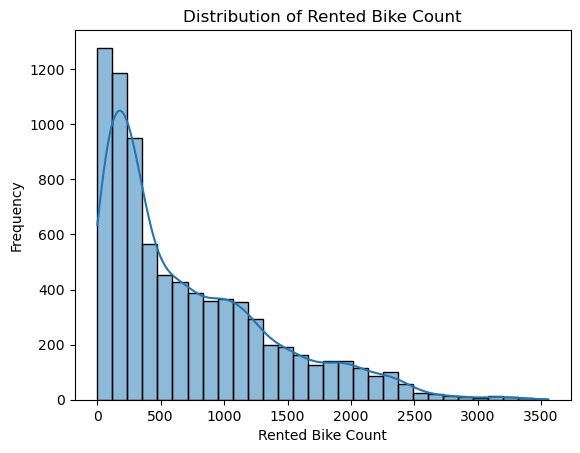

In [13]:
# 자전거 대여량이 어떤 구간에 몰려 있는지 시각적으로 표현
sns.histplot(df['Rented Bike Count'], bins=30, kde=True)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.show()

In [14]:
df['Rented Bike Count'].value_counts()

Rented Bike Count
0       223
103      18
223      18
262      18
165      17
       ... 
2191      1
1970      1
3113      1
2602      1
1907      1
Name: count, Length: 2138, dtype: int64

### **4-4 독립변수(설명변수) 데이터 확인**
#### 4-4.1 Date: 데이터가 수집된 날짜 (YYYY-MM-DD)

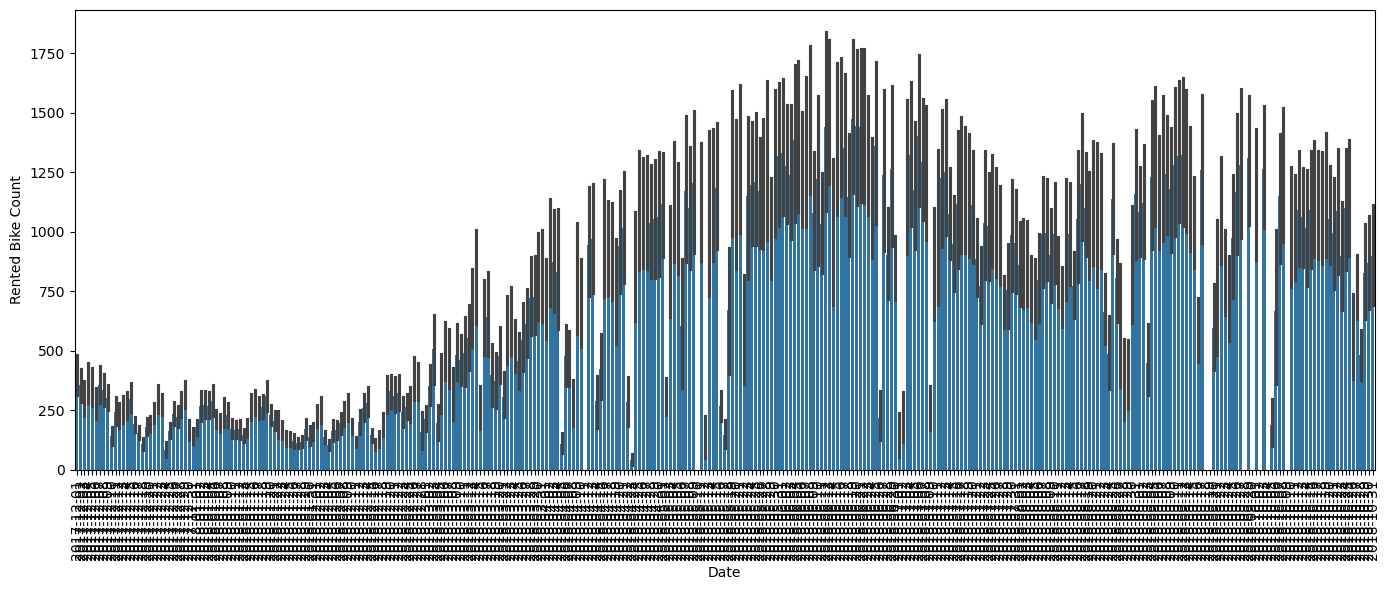

In [15]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Date', y='Rented Bike Count') 

plt.xticks(rotation=90)  # x축 레이블 45도 회전
plt.xlabel('Date')
plt.ylabel('Rented Bike Count')
plt.tight_layout()  # 레이아웃 자동 정리
plt.show()

-> 여름~가을쯤 자전거 대여량이 증가.

#### 4-4.2 Hour (24시간 기준, 0~23)	

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

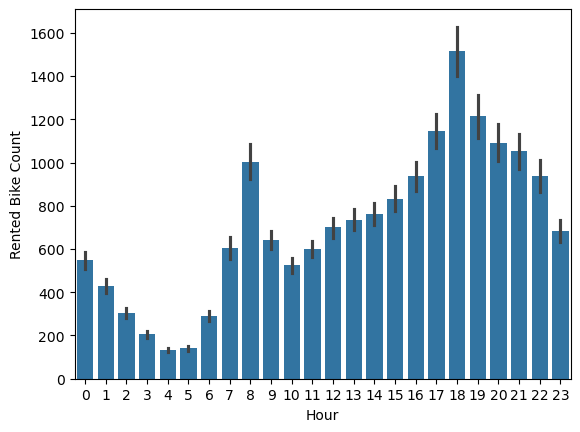

In [16]:
sns.barplot(data=df, x='Hour', y='Rented Bike Count',)

-> 출근(7~9시), 퇴근(17~19시)에 자전거 대여량 많음.

#### 4-4.3 Temperature(째C) 

In [17]:
print(df['Temperature(째C)'].min()) # –17.8 °C 
print(df['Temperature(째C)'].max()) # 39 °C
# 매우 드문 현상이나 극단적 한파와 폭염 상황에서 관찰될 수 있는 값이므로 이상치로 간주하지 않음.

-17.8
39.4


<Axes: xlabel='Temperature(째C)', ylabel='Rented Bike Count'>

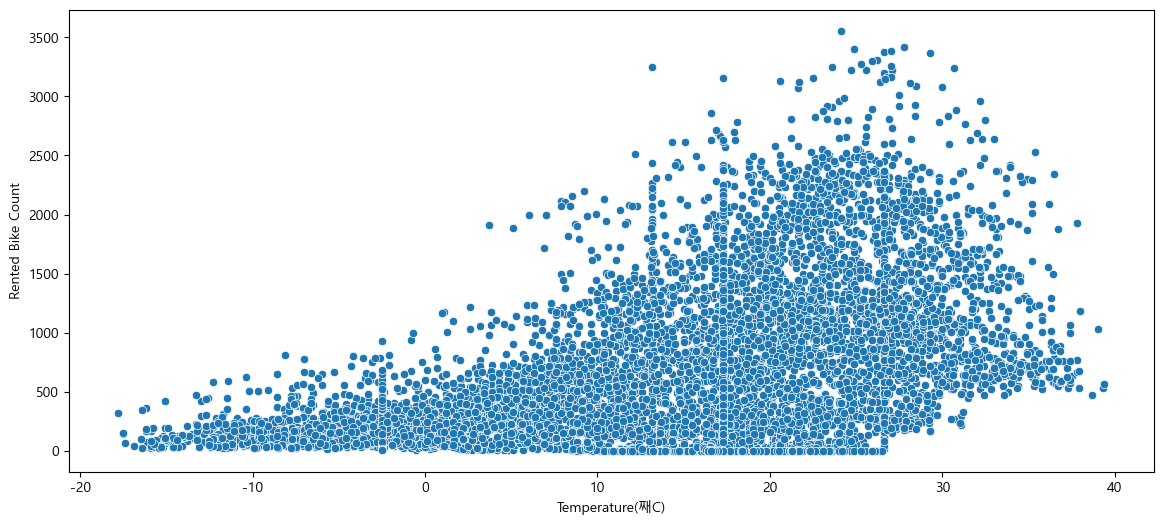

In [18]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 음수 깨짐 방지
plt.figure(figsize=(14, 6))  

sns.scatterplot(data=df, x="Temperature(째C)", y="Rented Bike Count")

-> 기온이 높아질수록 자전거 대여량도 증가하는 경향이 뚜렷

#### 4-4.4 Humidity(%)

In [19]:
df['Humidity(%)'].min() # humidity=0인 경우는 현실적으로 불가능함으로 이상치로 간주.

0

In [20]:
df[df['Humidity(%)'] == 0] # Seasons(=0, 봄)인 경우만 해당되므로 봄의 평균 이용해서 결측치를 채움. 

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
4063,2018-05-19,436,7,11.400000,0,1.400000,2000,4.5,0.46,0.0,0.0,0,0,1
4106,2018-05-21,262,2,13.900000,0,0.900000,2000,-2.1,0.00,0.0,0.0,0,0,1
4107,2018-05-21,165,3,13.000000,0,0.800000,2000,-2.5,0.00,0.0,0.0,0,0,1
4108,2018-05-21,113,4,12.400000,0,0.800000,2000,-3.4,0.00,0.0,0.0,0,0,1
4109,2018-05-21,200,5,11.900000,0,1.300000,2000,-2.7,0.00,0.0,0.0,0,0,1
4110,2018-05-21,467,6,11.400000,0,0.900000,2000,-2.0,0.03,0.0,0.0,0,0,1
4111,2018-05-21,1135,7,12.300000,0,1.867199,1989,-2.7,0.48,0.0,0.0,0,0,1
4131,2018-05-22,406,3,13.147726,0,0.700000,1420,10.4,0.00,0.0,0.0,0,1,1
4132,2018-05-22,248,4,15.600000,0,0.500000,1502,10.5,0.00,0.0,0.0,0,1,1
4133,2018-05-22,182,5,15.700000,0,0.600000,1610,10.6,0.00,0.0,0.0,0,1,1


In [21]:
# Humidity(%) 결측치 채우기 - 4-2.2) 참고
df['Humidity(%)'] = df.groupby('Seasons')['Humidity(%)'].transform(
    lambda x: x.fillna(x.mean()))

<Axes: xlabel='Humidity(%)', ylabel='Rented Bike Count'>

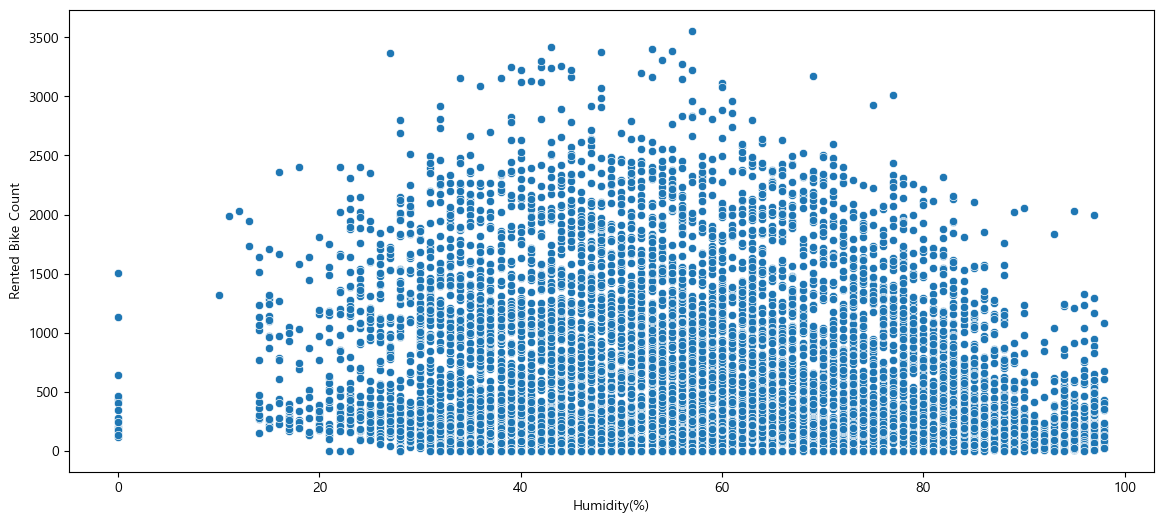

In [22]:
plt.figure(figsize=(14, 6))  

# 습도와 따릉이 대여량 관계
sns.scatterplot(data=df, x="Humidity(%)", y="Rented Bike Count")

#### 4-4.5 Wind speed (m/s)

In [23]:
df['Wind speed (m/s)'].max() # 7.4는 물리적으로 가능한 강풍으로 볼 수 있어 이상치로 간주하지 않음.

7.4

<Axes: xlabel='Wind speed (m/s)', ylabel='Rented Bike Count'>

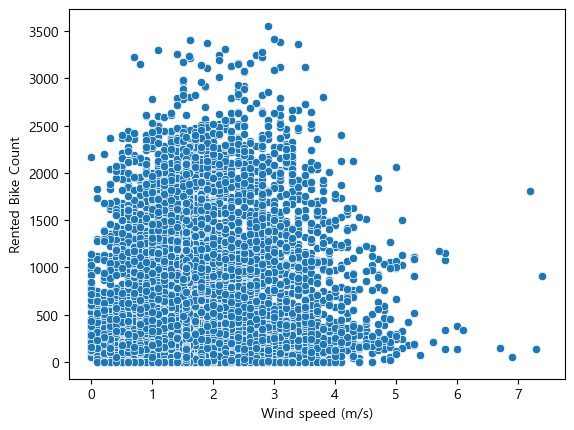

In [24]:
sns.scatterplot(data=df, x='Wind speed (m/s)', y='Rented Bike Count')

-> 강풍 시 자전거 대여량이 눈에 띄게 감소

#### 4-4.6 Visibility (10m)

<Axes: xlabel='Visibility (10m)', ylabel='Rented Bike Count'>

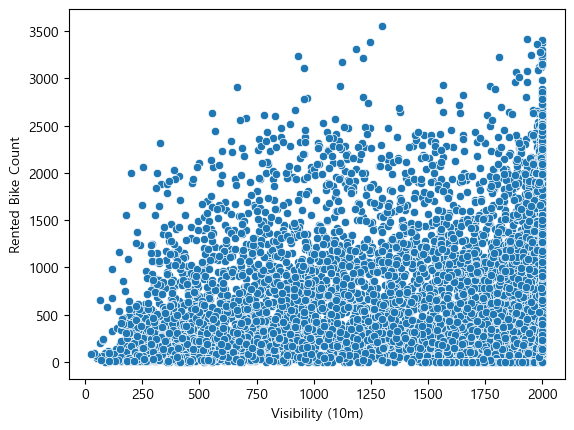

In [25]:
sns.scatterplot(data=df, x='Visibility (10m)', y='Rented Bike Count')

-> 전반적 양(+)의 상관관계를 보임. 시간대·교란변수 고려 필요.

#### 4-4.7 Dew point temperature(째C)

In [26]:
print(df['Dew point temperature(째C)'].min()) # -30.6
print(df['Dew point temperature(째C)'].max()) # 27.2
# 기상청 공식 자료에 의하면 이슬점은 –30°C 안팎의 극히 낮은 값부터 약 25~27°C
# (겨울 한파 시 매우 낮은 이슬점, 여름 무더위 시 매우 높은 이슬점)에 이르는 매우 높은 값까지 관측될 수 있으므로 이상치로 간주하지 않음.

-30.6
27.2


<Axes: xlabel='Dew point temperature(째C)', ylabel='Rented Bike Count'>

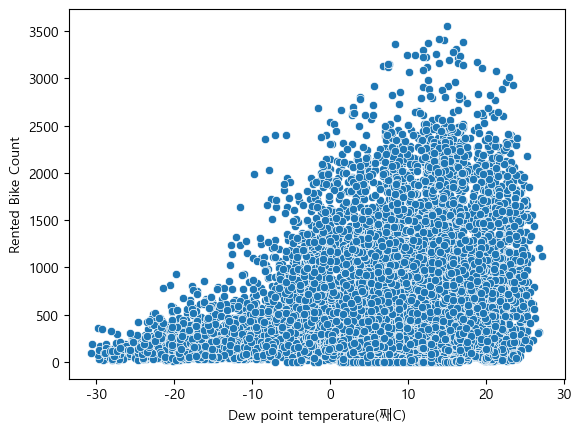

In [27]:
sns.scatterplot(data=df, x='Dew point temperature(째C)', y='Rented Bike Count')

-> “적당히 포근한” 이슬점(0 °C 초과 ~ 20 °C 이하), 특히 5~15 °C 구간에서 대여량이 가장 증가.

#### 4-4.8 Solar Radiation (MJ/m2)

In [28]:
print(df['Solar Radiation (MJ/m2)'].min()) # 0
print(df['Solar Radiation (MJ/m2)'].max()) # 3.52: 충분히 가능한 값

0.0
3.52


<Axes: xlabel='Solar Radiation (MJ/m2)', ylabel='Rented Bike Count'>

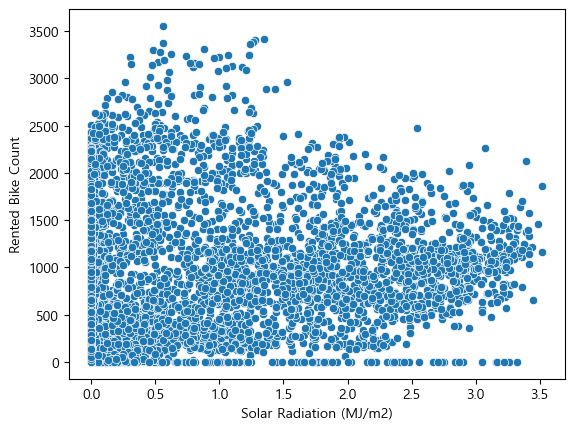

In [29]:
sns.scatterplot(data=df, x='Solar Radiation (MJ/m2)', y='Rented Bike Count')

#### 4-4.9 Rainfall(mm)

In [30]:
print(df['Rainfall(mm)'].min()) # 0
print(df['Rainfall(mm)'].max()) # 35: 충분히 가능한 값(집중호우, 장마 등)

0.0
35.0


<Axes: xlabel='Rainfall(mm)', ylabel='Rented Bike Count'>

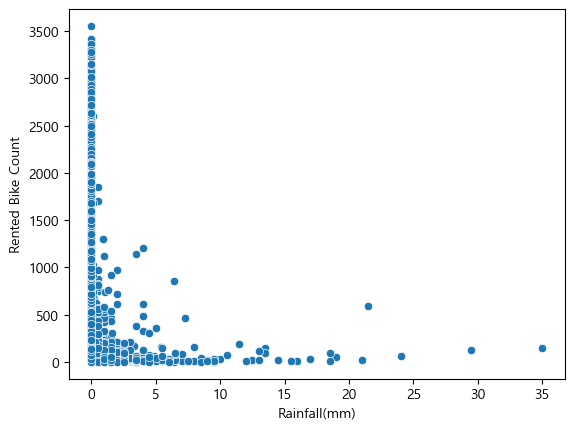

In [31]:
sns.scatterplot(data=df, x='Rainfall(mm)', y='Rented Bike Count')

-> 비가 조금씩 내리기만 해도(>0 mm) 자전거 대여량이 급격히 줄어들음

#### 4-4.10 Snowfall(cm)

In [32]:
print(df['Snowfall (cm)'].min()) # 0
print(df['Snowfall (cm)'].max()) # 5.1: 충분히 가능한 값(겨울철 대설)

0.0
5.1


<Axes: xlabel='Snowfall (cm)', ylabel='Rented Bike Count'>

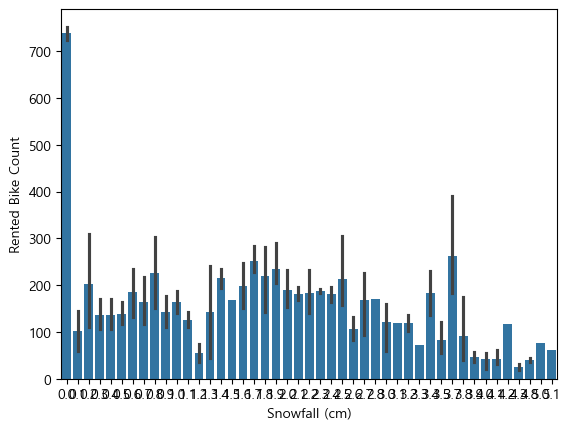

In [33]:
sns.barplot(data=df, x='Snowfall (cm)', y='Rented Bike Count')

-> 눈이 내리지 않을 때만 자전거 대여량이 많고 눈이 조금만 내려도 자전거 대여량이 줄어들음.

#### 4-4.11 Seasons(계절:봄,여름,가을,겨울)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

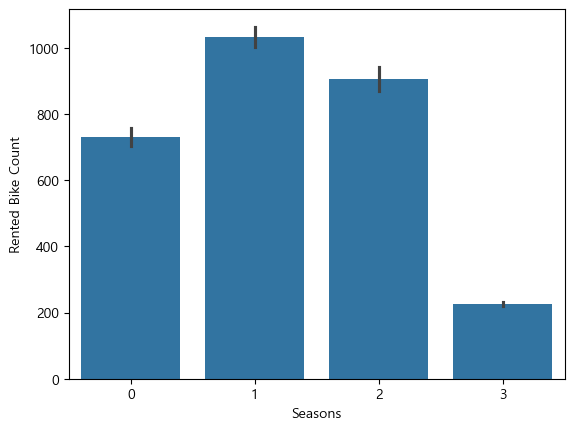

In [34]:
sns.barplot(data=df, x='Seasons', y='Rented Bike Count') # 0:봄, 1:여름, 2:가을, 3:겨울

#### 4-4.12 Holiday(공휴일 여부: 'Holiday' or 'No Holiday')

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

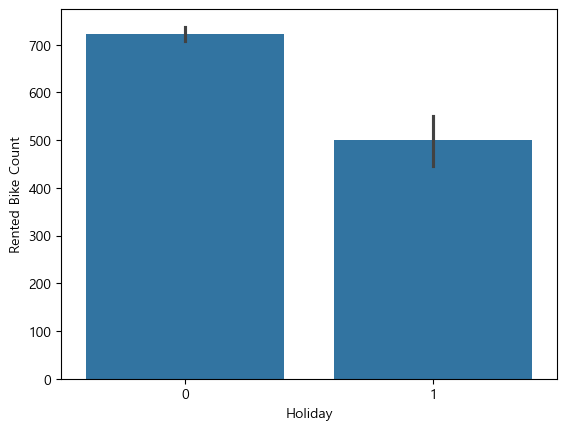

In [35]:
sns.barplot(data=df, x='Holiday', y='Rented Bike Count') # 0: 평일, 1: 휴일

-> 휴일보다 평일 자전거 대여량 더 많음. 

#### 4-4.13 Functioning Day: 자전거 대여 시스템이 정상 운영된 날 여부 (Yes or No)

<Axes: xlabel='Functioning Day', ylabel='Rented Bike Count'>

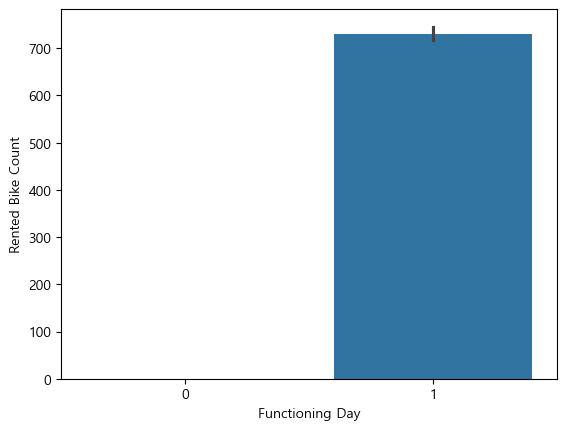

In [36]:
sns.barplot(data=df, x='Functioning Day', y='Rented Bike Count') # 0: 비운영일, 1: 운영일

-> 비운영일(0)에는 자전거 대여량이 없음.

# **5. 회귀모델(Linear Regression) 모델링**

In [37]:
# Date 로부터 Month만 뽑아내고 Date는 제거
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

In [38]:
df_a = df.copy()

### **5-1 목표변수(Y)와 설명변수(X)를 설정**

In [39]:
X = df_a.drop(columns=['Rented Bike Count'])
Y = df_a['Rented Bike Count']

### **5-2 학습 데이터(Train Set)와 검증 데이터(Test Set)분할**

In [40]:
from sklearn.model_selection import train_test_split 

train_test_split(X,Y)

[      Hour  Temperature(째C)  Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
 4156     4        15.000000           97          1.867199              1827   
 7026    18        24.000000           55          2.200000              1691   
 2516    20        10.500000           97          1.800000               372   
 36      12         4.300000           41          1.300000              1666   
 1116    12         5.200000           52          1.200000               349   
 ...    ...              ...          ...               ...               ...   
 7825     1        11.100000           62          0.200000               666   
 2103    15        10.300000           23          2.100000              1317   
 4997     5        26.610258           97          1.200000               402   
 7066    10        18.400000           96          2.000000              1124   
 7872     0        10.500000           75          0.300000              1800   
 
       Dew point temperatu

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)

### **5-3 선형 회귀 모델**

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
print(X_train.dtypes)
print(Y_train.dtype)

Hour                           int64
Temperature(째C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(째C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                        int64
Holiday                        int64
Functioning Day                int64
Month                          int32
dtype: object
int64


In [44]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [45]:
# 평가
from sklearn.metrics import r2_score, mean_squared_error

In [46]:
# 평가하는 함수
def eval_regression(model):
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    print('학습 능력')
    print('R Square : ', r2_score(Y_train, Y_train_pred))
    print('MSE : ', mean_squared_error(Y_train, Y_train_pred))
    print('일반화 능력')
    print('R Square : ', r2_score(Y_test, Y_test_pred))
    print('MSE : ', mean_squared_error(Y_test, Y_test_pred))

In [47]:
## model 평가
eval_regression(model)

학습 능력
R Square :  0.544878270407364
MSE :  197156.3717029578
일반화 능력
R Square :  0.5196223043586485
MSE :  205806.45284393546


R Square 
- 학습(train) 능력: 54.5%
- 일반화(test) 능력: 52.0%
- -> R Square  차이가 크지 않아(≈2.6%) 과적합이 심하지 않고 모델이 비교적 안정적으로 일반화되고 있음을 보여줌.


MSE 
- 학습 능력:  197156.3717029578 
- 일반화 능력:  205806.45284393546
- -> MSE의 단위는 ‘(자전거 대여량)²’이므로 실제 예측 오차의 크기를 직관적으로 보려면 RMSE(=√MSE)를 계산.

- 학습 RMSE ≈ √197,156 ≈ 444 대
- 테스트 RMSE ≈ √205,806 ≈ 454 대
- → 평균적으로 한 시간 예측 시 ±450대 정도 오차가 있음을 의미함.

### **5-4 다중 회귀 모델**

In [48]:
from sklearn.preprocessing import PolynomialFeatures
# 기존의 X값을 다항식으로 변환

In [49]:
X_train.columns # 칼럼의 개수: 13개

Index(['Hour', 'Temperature(째C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Dew point temperature(째C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Month'],
      dtype='object')

In [50]:
## 다항회귀분석 실행
X_poly = PolynomialFeatures(degree=2).fit_transform(X_train)
pd.DataFrame(X_poly) 

,0,1,2,3,4,5,6,7,8,9,...,95,96,97,98,99,100,101,102,103,104
0,1.0,11.0,33.600000,46.0,1.700000,1965.0,20.3,2.60,0.0,0.0,...,1.0,0.0,1.0,7.0,0.0,0.0,0.0,1.0,7.0,49.0
1,1.0,16.0,13.147726,53.0,3.700000,1735.0,7.8,1.40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,9.0
2,1.0,21.0,22.100000,44.0,2.500000,2000.0,9.2,0.00,0.0,0.0,...,1.0,0.0,1.0,6.0,0.0,0.0,0.0,1.0,6.0,36.0
3,1.0,11.0,13.147726,33.0,1.100000,892.0,-6.2,1.54,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,9.0
4,1.0,6.0,24.200000,96.0,1.600000,1206.0,23.5,0.00,0.0,0.0,...,1.0,0.0,1.0,8.0,0.0,0.0,0.0,1.0,8.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,1.0,12.0,15.500000,33.0,1.867199,1893.0,-0.7,3.10,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,16.0
6026,1.0,21.0,18.700000,48.0,1.300000,2000.0,7.4,0.00,0.0,0.0,...,4.0,0.0,2.0,18.0,0.0,0.0,0.0,1.0,9.0,81.0
6027,1.0,22.0,-15.200000,45.0,4.000000,2000.0,-24.4,0.00,0.0,0.7,...,9.0,0.0,3.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0
6028,1.0,3.0,0.300000,91.0,2.000000,172.0,-1.0,0.00,1.0,1.2,...,9.0,3.0,3.0,36.0,1.0,1.0,12.0,1.0,12.0,144.0


=> 13개로 만들 수 있는 조합 
- 상수항 1개: 
- 기존의 X1, .., X13: 13개
- X1^2, ..., X13^2: 13개
- 교차항 13C2 : 78개
- 따라서 1+13+13+78 = 105개

In [51]:
# 파이프 라인을 활용하여 다항 회귀 분석 수행
from sklearn.pipeline import make_pipeline
model_linear = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_linear.fit(X_train, Y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [52]:
eval_regression(model_linear)

학습 능력
R Square :  0.7042173080035428
MSE :  128131.52740202317
일반화 능력
R Square :  0.6804449074978712
MSE :  136905.81530492182


R Square 
- 학습(train) 능력:  70.5%
- 일반화(test) 능력: 68%
-> 1차 선형모델 대비 훨씬 더 많은 정보를 포착하고 있음을 보여줌.
-> 격차가 2.4%로 큰 과적합 없음.

MSE 
- 학습 RMSE ≈ √128,000 ≈ 358대
- 일반화 테스트 RMSE ≈ √136,900 ≈ 370대
- 평균 예측 오차가 ±450대(1차 선형회귀모델) → ±370대(다중 회귀모델)로 감소해 예측 정확도가 눈에 띄게 개선

### **5-5 규제 선형 회귀 모델**

#### 5-5.1 Lasso Model
- 선형회귀에 L1규제를 추가한 모델

In [53]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [54]:
model_pipe1 = make_pipeline(StandardScaler(), Lasso()) # 표준화 + lasso 회귀 적용하는 파이프라인
model_pipe1

Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso())])

In [55]:
hyperparam = {'lasso__alpha' : (0.5, 1, 1.5)} # alpha 값이 클수록 규제가 강해지고, 회귀계수가 더 작아짐
grid_model = GridSearchCV(model_pipe1, param_grid = hyperparam, cv=3, 
                          scoring='r2', n_jobs=-1)
grid_model.fit(X_train, Y_train)
best_model = grid_model.best_estimator_
best_model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.5))])

In [56]:
eval_regression(best_model)

학습 능력
R Square :  0.5448600602111511
MSE :  197164.26026546737
일반화 능력
R Square :  0.5200426040317112
MSE :  205626.38539777935


R Square 
- 학습(train) 능력: 54.5%
- 일반화(test) 능력: 52%
-> 격차가 2.5%로 과적합 없음.

MSE 
- 학습 RMSE ≈ √197,164 ≈ 444대
- 일반화 테스트 RMSE ≈ √205,626 ≈ 454대

In [57]:
best_model['lasso'].coef_ # 0으로 나온 애들은 규제 대상이 된 것.

array([ 198.02382221,  116.93122314, -271.17497785,   11.76899156,
         20.88324569,  278.04020448,  -69.80031952,  -65.93124723,
          9.81591885,  -67.1416996 ,  -27.15025225,  143.57744511,
         55.24710992])

In [58]:
df_coef = pd.DataFrame()
df_coef['Coef'] = best_model['lasso'].coef_
df_coef['X'] = X.columns

In [59]:
px.bar(df_coef, x='X', y='Coef')

-> 습도는 대여량을 크게 감소시키고 이슬점과 hour는 대여량을 크게 증가시키는 것으로 보임

#### 5-5.2 Ridge

- 선형회귀에 L2규제를 추가한 회귀 모델로 L2규제는 상대적으로 큰 회귀계수를 더 작게 만들어 편향을 줄이는 규제 모델

In [60]:
from sklearn.linear_model import Ridge

In [61]:
model_pipe2 = make_pipeline(StandardScaler(), Ridge())
model_pipe2

Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [62]:
hyperparam = {'ridge__alpha' : (0.1, 1, 1.5)}
grid_model = GridSearchCV(model_pipe2, param_grid = hyperparam, cv=3, 
                          scoring='r2', n_jobs=-1)
grid_model.fit(X_train, Y_train)
best_model2 = grid_model.best_estimator_
best_model2

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=1))])

In [63]:
eval_regression(best_model2) # L1 규제(Lasso)와 L2 규제(Ridge)가 비슷한 효과를 냄

학습 능력
R Square :  0.5448780177595601
MSE :  197156.4811486755
일반화 능력
R Square :  0.5196611060080325
MSE :  205789.8291957173


In [64]:
df_coef = pd.DataFrame()
df_coef['Coef'] = best_model2['ridge'].coef_
df_coef['X'] = X.columns

In [65]:
px.bar(df_coef, x='X', y='Coef')

-> Lasso와 비슷하게 습도는 대여량을 크게 감소시키고 이슬점과 hour는 대여량을 크게 증가시키는 것으로 보임


#### 5-5.3 Elastic Net
- L1 규제와 L2규제를 함께 결합한 모델

In [66]:
from sklearn.linear_model import ElasticNet

In [67]:
model_pipe3 = make_pipeline(StandardScaler(), ElasticNet())

In [68]:
hyperparam = {'elasticnet__alpha' : (0.1, 1, 1.5)}
grid_model = GridSearchCV(model_pipe3, param_grid = hyperparam, cv=3, 
                          scoring='r2', n_jobs=-1)
grid_model.fit(X_train, Y_train)
best_model3 = grid_model.best_estimator_
best_model3

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('elasticnet', ElasticNet(alpha=0.1))])

In [69]:
eval_regression(best_model3) 
# L1+L2 혼합 규제를 적용했을 때 테스트 성능(테스트 R², MSE)이 약간 더 우수. 
# 규제 선형 모델 중 가장 낮은 테스트 MSE와 높은 테스트 R²를 보여주기 때문에 3개 중엔 ElasticNet이 더 적합.

학습 능력
R Square :  0.5422846819694331
MSE :  198279.9007565384
일반화 능력
R Square :  0.522657471316026
MSE :  204506.10740543006


In [70]:
df_coef = pd.DataFrame()
df_coef['Coef'] = best_model3['elasticnet'].coef_
df_coef['X'] = X.columns

In [71]:
px.bar(df_coef, x='X', y='Coef')

-> 온도·시간·이슬점·운영일·월이 자전거 대여량을 증가시키고 습도·강수량·계절·일사량·휴일은 대여량을 감소시키는 것으로 보임

### **5-6 총정리**
- 다중회귀모델이 가장 적합함.
- 학습 R²가 0.704, 검증 R²가 0.680으로 가장 높고 MSE(≈136,900)도 가장 낮아 Lasso·Ridge·ElasticNet 등 보다 예측 성능이 뛰어남.